In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, TimeSeriesSplit
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import joblib

In [3]:
path = r'C:\Users\devan\Desktop\SAR_Work\final_df.csv'
df = pd.read_csv(path, index_col=0, parse_dates=True)
df.head()

,HOURLY_KWH,AVG_CURRENT,AVG_V_LN,original_data,power_proxy,hour,weekday,month,week_of_year,hour_sin,...,kwh_roll_3h_mean,kwh_roll_24h_mean,kwh_roll_24h_std,kwh_roll_24h_min,kwh_roll_24h_max,kwh_roll_168h_mean,kwh_roll_168h_std,kwh_ratio_to_24h_avg,kwh_ratio_to_168h_avg,Type
Time,,,,,,,,,,,,,,,,,,,,,
2025-07-29 20:00:00,2.911,4.934083,231.100833,True,1140.270770,20,1,7,31,-0.866025,...,2.701000,2.795417,0.225463,2.228,3.162,2.294809,0.665662,0.869637,1.059347,YWNC2 CONE
2025-07-29 21:00:00,3.162,5.462750,229.131000,True,1251.685370,21,1,7,31,-0.707107,...,2.750000,2.802500,0.226347,2.228,3.162,2.311784,0.644555,1.038715,1.259200,YWNC2 CONE
2025-07-29 22:00:00,2.629,5.446273,230.278455,True,1254.159267,22,1,7,31,-0.500000,...,2.834667,2.805042,0.230155,2.228,3.162,2.327682,0.632400,1.127256,1.358432,YWNC2 CONE
2025-07-29 23:00:00,2.672,4.424583,230.528333,True,1019.991822,23,1,7,31,-0.258819,...,2.900667,2.793417,0.231769,2.228,3.162,2.336257,0.626659,0.941141,1.125304,YWNC2 CONE
2025-07-30 00:00:00,2.694,5.329182,230.007636,True,1225.752514,0,2,7,31,0.000000,...,2.821000,2.799958,0.225706,2.228,3.162,2.344820,0.621364,0.954300,1.139533,YWNC2 CONE


In [49]:
import os

print(os.cpu_count())

12


In [50]:
import xgboost as xgb
print(xgb.__version__)

3.1.2


In [4]:
df3cone = df[df["Type"] == "YWNC3 CONE"].drop(columns="Type")

In [9]:
df3cone[df3cone['Off'] == 1].max()

HOURLY_KWH                    0.122
AVG_CURRENT                   3.097
AVG_V_LN                 245.457857
original_data                  True
power_proxy              716.915239
hour                             23
weekday                           6
month                            12
week_of_year                     52
hour_sin                        1.0
hour_cos                        1.0
weekday_sin                0.974928
weekday_cos                     1.0
month_sin                  0.866025
month_cos                       1.0
Shift_A                           1
Shift_B                           1
Shift_C                           1
Off                               1
kwh_lag_1                     1.135
kwh_lag_2                     1.245
kwh_lag_24                    3.123
kwh_lag_168                   2.826
kwh_roll_3h_mean              1.088
kwh_roll_24h_mean          2.092375
kwh_roll_24h_std           1.112102
kwh_roll_24h_min              0.713
kwh_roll_24h_max            

In [47]:
print(f"YWNC2 CONE->0.05 quantile: {df[df['Type'] == 'YWNC2 CONE']['HOURLY_KWH'].quantile(0.2)}")
print(f"YWNC2 CUP->0.05 quantile: {df[df['Type'] == 'YWNC2 CUP']['HOURLY_KWH'].quantile(0.2)}")
print(f"YWNC3 CONE->0.05 quantile: {df[df['Type'] == 'YWNC3 CONE']['HOURLY_KWH'].quantile(0.2)}")
print(f"YWNC3 CUP->0.05 quantile: {df[df['Type'] == 'YWNC3 CUP']['HOURLY_KWH'].quantile(0.2)}")

YWNC2 CONE->0.05 quantile: 0.6971999999994298
YWNC2 CUP->0.05 quantile: 0.5304000000007364
YWNC3 CONE->0.05 quantile: 0.35340000000032895
YWNC3 CUP->0.05 quantile: 0.3975909090906498


In [48]:
for machine in df["Type"].unique():
    subset = df[df["Type"] == machine]["HOURLY_KWH"]

    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1

    print(f"\nMachine: {machine}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")



Machine: YWNC2 CONE
Q1: 1.0112499999991087
Q3: 1.459000000000742
IQR: 0.44775000000163323

Machine: YWNC2 CUP
Q1: 0.865750000000844
Q3: 1.7029999999995198
IQR: 0.8372499999986758

Machine: YWNC3 CONE
Q1: 0.6032500000005712
Q3: 1.306238636363291
IQR: 0.7029886363627198

Machine: YWNC3 CUP
Q1: 0.7072500000003856
Q3: 1.9809999999997672
IQR: 1.2737499999993815


In [ ]:
print("YWNC2 CONE")
print(f"0.5 quantile {df["HOURLY_KWH"].quantile(0.05)}")
df[df["Type"]=="YWNC2 CONE"].groupby("Off")["HOURLY_KWH"].describe()


YWNC2 CONE


,count,mean,std,min,25%,50%,75%,max
Off,,,,,,,,
0,4386.0,1.293419,0.581410,0.150,1.107,1.326,1.468,3.591
1,232.0,0.132578,0.017592,0.015,0.125,0.138,0.144,0.150


In [16]:
print("YWNC3 CONE")
df[df["Type"]=="YWNC3 CONE"].groupby("Off")["HOURLY_KWH"].describe()

YWNC3 CONE


,count,mean,std,min,25%,50%,75%,max
Off,,,,,,,,
0,4374.0,1.135471,0.691431,0.122,0.684,1.0315,1.34145,3.357
1,244.0,0.111025,0.014134,0.040,0.112,0.1150,0.12000,0.122


In [17]:
print("YWNC2 CUP")
df[df["Type"]=="YWNC2 CUP"].groupby("Off")["HOURLY_KWH"].describe()

YWNC2 CUP


,count,mean,std,min,25%,50%,75%,max
Off,,,,,,,,
0,4379.0,1.399464,0.688586,0.148,1.1505,1.537182,1.712,4.110
1,239.0,0.128705,0.024761,0.039,0.1175,0.140000,0.144,0.148


In [18]:
print("YWNC3 CUP")
df[df["Type"]=="YWNC3 CUP"].groupby("Off")["HOURLY_KWH"].describe()

YWNC3 CUP


,count,mean,std,min,25%,50%,75%,max
Off,,,,,,,,
0,4353.0,1.444639,0.709782,0.144,0.931,1.700,2.005,3.546
1,265.0,0.120449,0.028268,0.016,0.085,0.139,0.142,0.143


In [36]:
bundle_path = r"C:\Users\devan\Desktop\SAR_Work\forecasting_ready_bundle.pkl"
bundle = joblib.load(bundle_path)

models = bundle["models"]
feature_cols = bundle["feature_columns"]


🔎 Feature Importance for: YWNC2_CONE
               Feature  Importance
0          AVG_CURRENT    0.355103
3          power_proxy    0.248093
18           kwh_lag_1    0.152932
26    kwh_roll_24h_max    0.100318
17                 Off    0.041642
22    kwh_roll_3h_mean    0.040388
13           month_cos    0.008526
27  kwh_roll_168h_mean    0.008098
7         week_of_year    0.005618
19           kwh_lag_2    0.005424


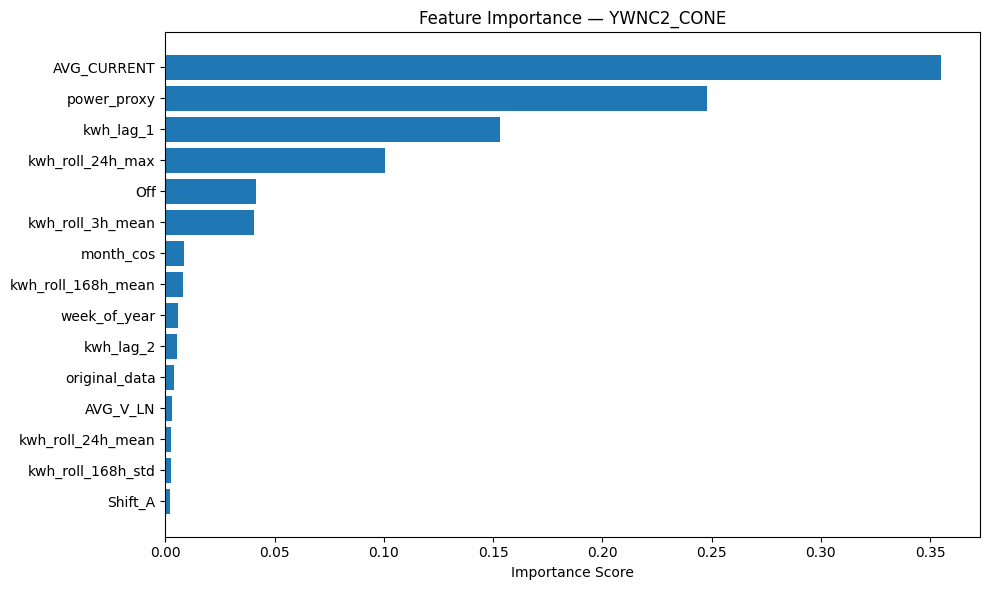


🔎 Feature Importance for: YWNC2_CUP
               Feature  Importance
3          power_proxy    0.586390
0          AVG_CURRENT    0.151800
22    kwh_roll_3h_mean    0.070361
18           kwh_lag_1    0.060809
17                 Off    0.037304
27  kwh_roll_168h_mean    0.024628
7         week_of_year    0.019996
26    kwh_roll_24h_max    0.018028
23   kwh_roll_24h_mean    0.003747
2        original_data    0.003382


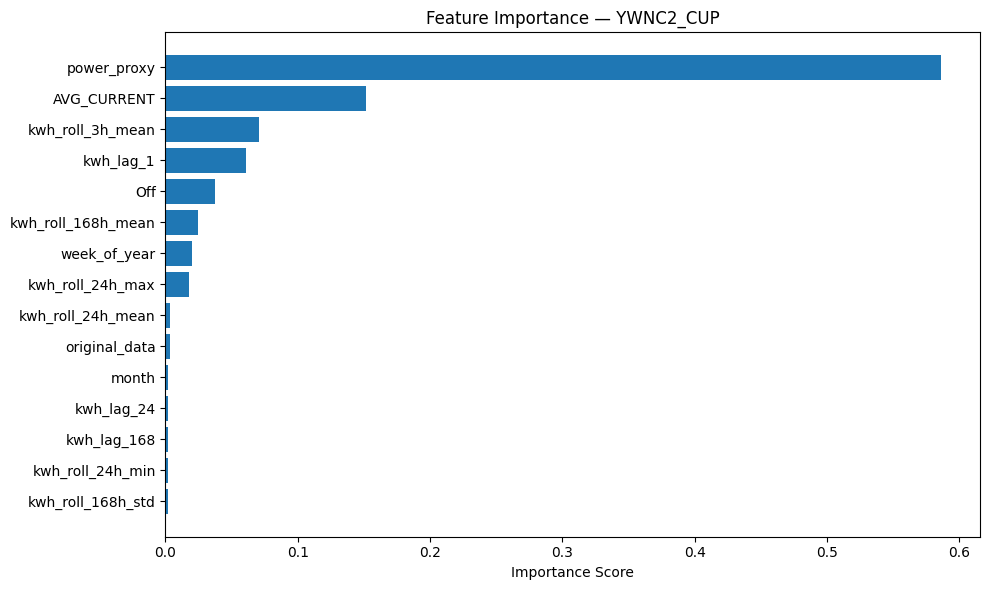


🔎 Feature Importance for: YWNC3_CONE
               Feature  Importance
3          power_proxy    0.570126
27  kwh_roll_168h_mean    0.287882
0          AVG_CURRENT    0.069656
2        original_data    0.014620
17                 Off    0.012054
18           kwh_lag_1    0.011563
26    kwh_roll_24h_max    0.006819
28   kwh_roll_168h_std    0.002116
13           month_cos    0.001825
22    kwh_roll_3h_mean    0.001728


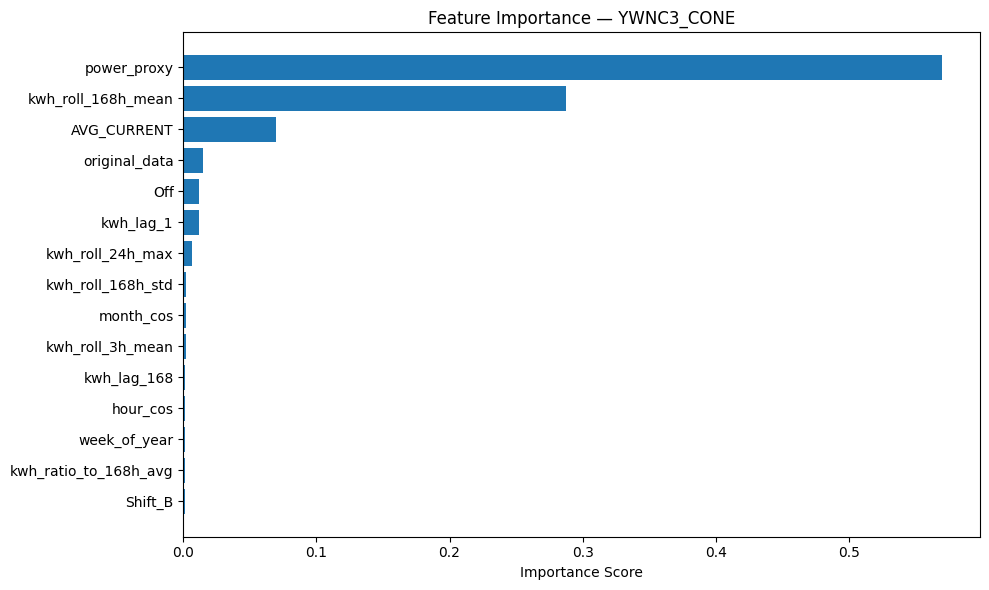


🔎 Feature Importance for: YWNC3_CUP
              Feature  Importance
0         AVG_CURRENT    0.703777
3         power_proxy    0.086513
26   kwh_roll_24h_max    0.082460
18          kwh_lag_1    0.061371
17                Off    0.023691
6               month    0.019087
22   kwh_roll_3h_mean    0.002909
28  kwh_roll_168h_std    0.002438
1            AVG_V_LN    0.001505
19          kwh_lag_2    0.001382


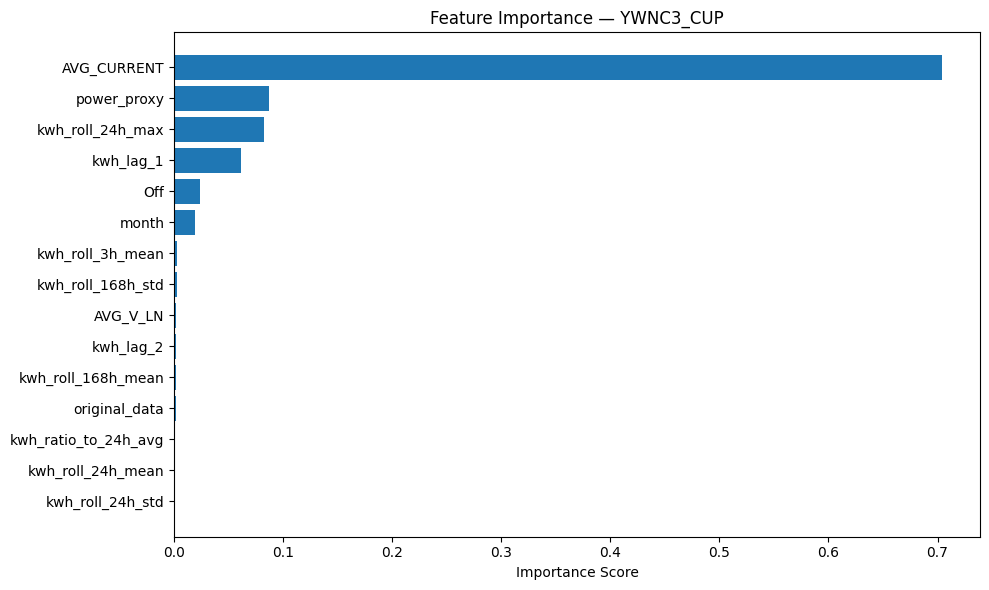

In [37]:
for machine_name, model in models.items():

    print(f"\n🔎 Feature Importance for: {machine_name}")

    # Get importance values
    importance = model.feature_importances_

    # Create dataframe
    df_imp = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

    # Print top features
    print(df_imp.head(10))

    # ---------------------------------------------------
    # PLOT GRAPH
    # ---------------------------------------------------
    plt.figure(figsize=(10, 6))

    # Plot top 15 features only for clarity
    df_plot = df_imp.head(15)

    plt.barh(df_plot["Feature"], df_plot["Importance"])
    plt.xlabel("Importance Score")
    plt.title(f"Feature Importance — {machine_name}")
    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

In [32]:
df_imp[df_imp["Machine"] == "YWNC3_CUP"].head()

,Feature,Importance,Machine
0,AVG_CURRENT,0.703777,YWNC3_CUP
3,power_proxy,0.086513,YWNC3_CUP
26,kwh_roll_24h_max,0.082460,YWNC3_CUP
18,kwh_lag_1,0.061371,YWNC3_CUP
17,Off,0.023691,YWNC3_CUP


In [33]:
df_imp[df_imp["Machine"] == "YWNC3_CONE"].head()

,Feature,Importance,Machine


In [35]:
df_imp['Machine'].nunique()

1

In [25]:
for machine, model in models.items():
    df_imp = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)

    df_imp.to_excel(f"{machine}_importance.xlsx", index=False)